# Notebook 01 — Baseline Model: CRNN (CNN + BiLSTM + CTC)
### CM4609 Individual Research Project — Handwritten Prescription Medicine Name Recognition


##  Environment & configuration

**MPS note (important for the thesis methodology section):** PyTorch's `nn.CTCLoss` has
no native Metal (MPS) kernel, so we enable the official CPU fallback
(`PYTORCH_ENABLE_MPS_FALLBACK=1`) **before importing torch**. The forward/backward pass
of the network runs on the M-series GPU; only the (cheap) CTC loss computation falls back
to CPU. This is the standard, documented workaround and costs little for word-sized inputs.

**Understand for the viva:** why must the env var be set before `import torch`?
(Because the MPS backend reads it once at library initialisation.)

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # must precede `import torch`

import math
import random
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# ---- Reproducibility -------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Device ----------------------------------------------------------------
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE} | torch {torch.__version__}")

Using device: mps | torch 2.12.0


In [2]:
@dataclass
class Config:
    """Single source of truth for every experimental knob.

    Keeping ALL hyperparameters here (rather than scattered through cells) means the
    thesis methodology table can be generated from one place, and experiments are
    reproducible from the saved config.
    """
    # --- Data: BD prescription dataset layout (edit paths for your machine) ---
    # Expected: a labels CSV with one row per image. Column names are configurable
    # so the SAME notebook runs on the custom pharmacy dataset later.
    data_root: Path = Path("../data/pharmacy_lk")
    train_csv: str = "splits/train.csv"
    train_img_dir: str = "images"
    val_csv: str = "splits/val.csv"
    val_img_dir: str = "images"
    test_csv: str = "splits/test.csv"
    test_img_dir: str = "images"
    img_col: str = "image_filename"      # column holding the image filename
    label_col: str = "medicine_name"# column holding the ground-truth transcription

    # --- Preprocessing ---
    img_height: int = 32            # CRNN canonical input height (Shi et al., 2017)
    max_width: int = 320            # cap; medicine names are short words
    pad_value: float = 1.0          # pad with white (images normalised to [0,1] first)

    # --- Model ---
    rnn_hidden: int = 256
    rnn_layers: int = 2
    dropout: float = 0.2

    # --- Training ---
    batch_size: int = 64
    epochs: int = 100
    lr: float = 3e-4
    weight_decay: float = 1e-4
    grad_clip: float = 5.0
    num_workers: int = 2            # keep modest on macOS
    ckpt_dir: Path = Path("checkpoints/baseline_crnn")

CFG = Config()
CFG.ckpt_dir.mkdir(parents=True, exist_ok=True)

## 3. Vocabulary and CTC label encoding

CTC reserves index **0 for the blank symbol**; real characters start at index 1.
The character set is built **from the training labels only** (building it from
val/test would be a subtle form of information leakage worth mentioning in the
methodology chapter).

**Understand for the viva:** what does the CTC blank do? (It separates repeated
characters and absorbs timesteps with no emission, enabling alignment-free training.)

In [3]:
class Vocab:
    """Bidirectional mapping char <-> index, with index 0 reserved for CTC blank."""

    BLANK = 0

    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.idx2char = {i + 1: c for i, c in enumerate(chars)}
        self.char2idx = {c: i for i, c in self.idx2char.items()}

    def __len__(self):
        return len(self.idx2char) + 1  # +1 for blank

    def encode(self, text: str) -> list[int]:
        return [self.char2idx[c] for c in text]

    def decode_greedy(self, indices: list[int]) -> str:
        """Collapse repeats, then drop blanks (standard CTC greedy decoding)."""
        out, prev = [], None
        for i in indices:
            if i != prev and i != self.BLANK:
                out.append(self.idx2char[i])
            prev = i
        return "".join(out)

## 4. Dataset and preprocessing

Pipeline per image: load → greyscale → resize to height 32 preserving aspect ratio →
cap width → normalise to [0,1] → (train only) light augmentation → pad to batch width.

Augmentation is deliberately conservative (small rotation/shear): aggressive geometric
distortion can turn one medicine name into a look-alike of another, corrupting labels —
a domain-specific risk worth a sentence in the thesis.

**Understand for the viva:** why pad with white rather than black? (Prescription
backgrounds are paper-white; padding should be indistinguishable from background so
the CNN does not learn artificial edge features at pad boundaries.)

In [4]:
class WordImageDataset(Dataset):
    def __init__(self, csv_path: Path, img_dir: Path, cfg: Config,
                 vocab: Vocab | None = None, augment: bool = False):
        self.df = pd.read_csv(csv_path)
        # Defensive cleaning: drop rows with missing labels, coerce to str, strip spaces
        self.df = self.df.dropna(subset=[cfg.label_col])
        self.df[cfg.label_col] = self.df[cfg.label_col].astype(str).str.strip()
        self.img_dir = Path(img_dir)
        self.cfg = cfg
        self.augment = augment
        self.vocab = vocab  # set after construction for the training set

    def labels(self) -> list[str]:
        return self.df[self.cfg.label_col].tolist()

    def __len__(self):
        return len(self.df)

    def _load_and_resize(self, path: Path) -> Image.Image:
        img = Image.open(path).convert("L")
        w, h = img.size
        new_w = max(8, int(round(w * self.cfg.img_height / h)))
        new_w = min(new_w, self.cfg.max_width)
        return img.resize((new_w, self.cfg.img_height), Image.BILINEAR)

    def _augment(self, img: Image.Image) -> Image.Image:
        # Small random rotation; expand=False keeps geometry, fill with white
        angle = random.uniform(-3.0, 3.0)
        return img.rotate(angle, resample=Image.BILINEAR, fillcolor=255)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_and_resize(self.img_dir / str(row[self.cfg.img_col]))
        if self.augment:
            img = self._augment(img)
        x = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)  # (1,H,W)
        text = row[self.cfg.label_col]
        target = torch.tensor(self.vocab.encode(text), dtype=torch.long)
        return x, target, text


def collate(batch, pad_value: float):
    """Pad images to the widest in the batch; concatenate targets for CTC."""
    xs, targets, texts = zip(*batch)
    max_w = max(x.shape[-1] for x in xs)
    padded = torch.stack([
        F.pad(x, (0, max_w - x.shape[-1]), value=pad_value) for x in xs
    ])                                                  # (N, 1, H, maxW)
    target_lengths = torch.tensor([t.numel() for t in targets], dtype=torch.long)
    targets_cat = torch.cat(targets)                    # CTC takes concatenated targets
    return padded, targets_cat, target_lengths, list(texts)

## 5. The CRNN architecture

The convolutional stack follows Shi et al. (2017): seven conv layers with pooling that
halves width twice but height four times, so a 32-px-high input becomes a height-1
feature map — i.e. a pure left-to-right feature **sequence** of width ≈ W/4. Two BiLSTM
layers then model sequential context, and a linear head emits per-timestep character
logits for CTC.

**Understand for the viva (sequence-length arithmetic):** CTC requires
`input_length ≥ target_length`. With `max_width=160`, the sequence length is
160/4 − 1 = 39 timesteps, comfortably above the longest medicine-name label.
If you ever change pooling, re-derive this.

In [5]:
class CRNN(nn.Module):
    def __init__(self, n_classes: int, rnn_hidden: int = 256,
                 rnn_layers: int = 2, dropout: float = 0.2):
        super().__init__()

        def conv(in_c, out_c, bn=False):
            layers = [nn.Conv2d(in_c, out_c, 3, 1, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        self.cnn = nn.Sequential(
            *conv(1, 64),    nn.MaxPool2d(2, 2),    # 32xW   -> 16 x W/2
            *conv(64, 128),  nn.MaxPool2d(2, 2),    #        ->  8 x W/4
            *conv(128, 256), *conv(256, 256),
            nn.MaxPool2d((2, 1), (2, 1)),           #        ->  4 x W/4 (height only)
            *conv(256, 512, bn=True), *conv(512, 512, bn=True),
            nn.MaxPool2d((2, 1), (2, 1)),           #        ->  2 x W/4
            nn.Conv2d(512, 512, 2, 1, 0), nn.ReLU(inplace=True),  # -> 1 x (W/4 - 1)
        )
        self.rnn = nn.LSTM(
            input_size=512, hidden_size=rnn_hidden, num_layers=rnn_layers,
            bidirectional=True, dropout=dropout if rnn_layers > 1 else 0.0,
        )
        self.head = nn.Linear(2 * rnn_hidden, n_classes)

    def forward(self, x):                 # x: (N, 1, 32, W)
        f = self.cnn(x)                   # (N, 512, 1, T)
        f = f.squeeze(2).permute(2, 0, 1) # (T, N, 512)  — sequence-first for LSTM/CTC
        seq, _ = self.rnn(f)              # (T, N, 2*hidden)
        return self.head(seq)             # (T, N, n_classes) — raw logits

    @staticmethod
    def output_lengths(input_widths: torch.Tensor) -> torch.Tensor:
        """Map padded image widths to CTC input_lengths (must mirror the CNN strides)."""
        return torch.div(input_widths, 4, rounding_mode="floor") - 1

### 5.1 Shape smoke test
Always verify tensor shapes with a dummy batch before training — cheap insurance
against silent broadcasting bugs (and good evidence of testing practice for the
implementation subgrade).

In [6]:
_dummy = torch.randn(2, 1, CFG.img_height, CFG.max_width)
_model_tmp = CRNN(n_classes=40)
with torch.no_grad():
    _out = _model_tmp(_dummy)
print(f"Input {tuple(_dummy.shape)} -> logits {tuple(_out.shape)}  (T, N, C)")
assert _out.shape[1] == 2
del _model_tmp, _dummy, _out

Input (2, 1, 32, 320) -> logits (79, 2, 40)  (T, N, C)


## 6. Metrics: CER, WER, Exact Match

- **CER** (character error rate) = edit distance / reference length. The primary HTR
  metric; sensitive to partial correctness.
- **Exact Match Accuracy** — the clinically meaningful metric here: a medicine name
  that is 90% correct may still be the *wrong drug* (look-alike names), so partial
  credit is misleading for deployment claims.
- **WER** — for single-word samples, WER = 1 − exact match; reported for comparability
  with multi-word literature.

Implemented dependency-free so the functions are reusable in the evaluation notebook.

In [7]:
def edit_distance(a: str, b: str) -> int:
    """Levenshtein distance, O(len(a)*len(b)) dynamic programming."""
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i]
        for j, cb in enumerate(b, 1):
            curr.append(min(prev[j] + 1,            # deletion
                            curr[j - 1] + 1,        # insertion
                            prev[j - 1] + (ca != cb)))  # substitution
        prev = curr
    return prev[-1]


def corpus_metrics(preds: list[str], refs: list[str]) -> dict:
    assert len(preds) == len(refs) and len(refs) > 0
    total_ed = sum(edit_distance(p, r) for p, r in zip(preds, refs))
    total_chars = sum(len(r) for r in refs)
    exact = sum(p == r for p, r in zip(preds, refs))
    return {
        "CER": total_ed / max(total_chars, 1),
        "ExactMatch": exact / len(refs),
        "WER": 1.0 - exact / len(refs),   # single-word samples
        "n": len(refs),
    }

# Unit checks — tiny, but they demonstrate correctness-by-construction
assert edit_distance("amoxicillin", "amoxicillin") == 0
assert edit_distance("amoxicillin", "amoxicilin") == 1
assert corpus_metrics(["abc"], ["abd"])["CER"] == 1/3

## 7. Data loading
Build the vocabulary from **training labels only**, then share it with val/test.

train=3696  val=792  test=793  classes=44


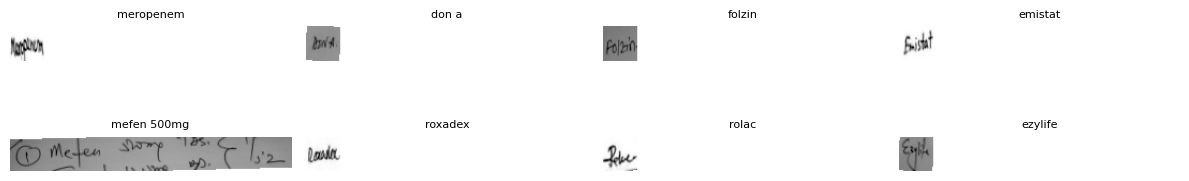

In [8]:
train_ds = WordImageDataset(CFG.data_root / CFG.train_csv, CFG.data_root / CFG.train_img_dir,
                            CFG, augment=True)
VOCAB = Vocab(train_ds.labels())
train_ds.vocab = VOCAB

val_ds = WordImageDataset(CFG.data_root / CFG.val_csv, CFG.data_root / CFG.val_img_dir,
                          CFG, vocab=VOCAB)
test_ds = WordImageDataset(CFG.data_root / CFG.test_csv, CFG.data_root / CFG.test_img_dir,
                           CFG, vocab=VOCAB)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}  classes={len(VOCAB)}")

def collate_fn(b):
    return collate(b, CFG.pad_value)

train_dl = DataLoader(train_ds, CFG.batch_size, shuffle=True,
                      num_workers=0, collate_fn=collate_fn, drop_last=True)
val_dl   = DataLoader(val_ds, CFG.batch_size, shuffle=False,
                      num_workers=0, collate_fn=collate_fn)
test_dl  = DataLoader(test_ds, CFG.batch_size, shuffle=False,
                      num_workers=0, collate_fn=collate_fn)

# Sanity-visualise a batch
xb, tb, tl, texts = next(iter(train_dl))
fig, axes = plt.subplots(2, 4, figsize=(12, 3))
for ax, img, txt in zip(axes.flat, xb, texts):
    ax.imshow(img.squeeze(0), cmap="gray"); ax.set_title(txt, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 8. Training loop

AdamW + gradient clipping + ReduceLROnPlateau on validation CER; best checkpoint kept
by validation CER. `zero_infinity=True` guards against the (rare) degenerate case where
a target is longer than the input sequence.

**Understand for the viva:** why is the *log-softmax over the class dimension* required
before `nn.CTCLoss`? (CTC expects log-probabilities; passing raw logits silently
produces wrong gradients.)

In [9]:
def greedy_decode(logits: torch.Tensor, vocab: Vocab) -> list[str]:
    """logits: (T, N, C) -> list of N decoded strings."""
    idx = logits.argmax(-1).permute(1, 0)  # (N, T)
    return [vocab.decode_greedy(seq.tolist()) for seq in idx]


@torch.no_grad()
def evaluate(model, loader, vocab) -> tuple[dict, list[str], list[str]]:
    model.eval()
    preds, refs = [], []
    for xb, _, _, texts in loader:
        logits = model(xb.to(DEVICE))
        preds += greedy_decode(logits.cpu(), vocab)
        refs += texts
    return corpus_metrics(preds, refs), preds, refs


def train(model, train_dl, val_dl, cfg: Config, vocab: Vocab):
    model.to(DEVICE)
    ctc = nn.CTCLoss(blank=Vocab.BLANK, zero_infinity=True)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

    history, best_cer = [], float("inf")
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0, running = time.time(), 0.0
        for xb, targets, target_lengths, _ in train_dl:
            xb = xb.to(DEVICE)
            logits = model(xb)                                  # (T, N, C) on MPS
            log_probs = logits.log_softmax(2)
            T = logits.shape[0]
            input_lengths = torch.full((xb.shape[0],), T, dtype=torch.long)
            # CTC loss has no MPS kernel: computed on CPU via fallback / explicit move
            loss = ctc(log_probs.cpu(), targets, input_lengths, target_lengths)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            running += loss.item() * xb.shape[0]

        train_loss = running / len(train_dl.dataset)
        val_metrics, _, _ = evaluate(model, val_dl, vocab)
        sched.step(val_metrics["CER"])
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})
        print(f"epoch {epoch:3d} | loss {train_loss:.4f} | "
              f"val CER {val_metrics['CER']:.4f} | val EM {val_metrics['ExactMatch']:.4f} | "
              f"{time.time()-t0:.1f}s")

        if val_metrics["CER"] < best_cer:
            best_cer = val_metrics["CER"]
            torch.save({"model": model.state_dict(), "vocab": VOCAB.idx2char,
                        "config": vars(cfg) | {"data_root": str(cfg.data_root),
                                               "ckpt_dir": str(cfg.ckpt_dir)}},
                       cfg.ckpt_dir / "best.pt")
    return pd.DataFrame(history)


model = CRNN(n_classes=len(VOCAB), rnn_hidden=CFG.rnn_hidden,
             rnn_layers=CFG.rnn_layers, dropout=CFG.dropout)
n_params = sum(p.numel() for p in model.parameters())
print(f"CRNN parameters: {n_params/1e6:.2f}M")

history = train(model, train_dl, val_dl, CFG, VOCAB)

CRNN parameters: 8.73M
epoch   1 | loss 4.7600 | val CER 1.0000 | val EM 0.0000 | 20.7s
epoch   2 | loss 3.2856 | val CER 1.0000 | val EM 0.0000 | 15.2s
epoch   3 | loss 3.2423 | val CER 1.0000 | val EM 0.0000 | 14.7s
epoch   4 | loss 3.2298 | val CER 0.9608 | val EM 0.0000 | 13.6s
epoch   5 | loss 3.1280 | val CER 0.9028 | val EM 0.0000 | 12.3s
epoch   6 | loss 3.1273 | val CER 0.8806 | val EM 0.0000 | 14.0s
epoch   7 | loss 3.0489 | val CER 0.8745 | val EM 0.0000 | 13.6s
epoch   8 | loss 3.0124 | val CER 0.8670 | val EM 0.0000 | 12.9s
epoch   9 | loss 2.9913 | val CER 0.8796 | val EM 0.0000 | 13.3s
epoch  10 | loss 2.9251 | val CER 0.8681 | val EM 0.0000 | 12.8s
epoch  11 | loss 2.9098 | val CER 0.9097 | val EM 0.0000 | 12.8s
epoch  12 | loss 2.9293 | val CER 0.8642 | val EM 0.0013 | 13.1s
epoch  13 | loss 2.8410 | val CER 0.8451 | val EM 0.0164 | 12.3s
epoch  14 | loss 2.8443 | val CER 0.8986 | val EM 0.0000 | 12.4s
epoch  15 | loss 2.8658 | val CER 0.9015 | val EM 0.0000 | 13.0s
ep

## 9. Learning curves

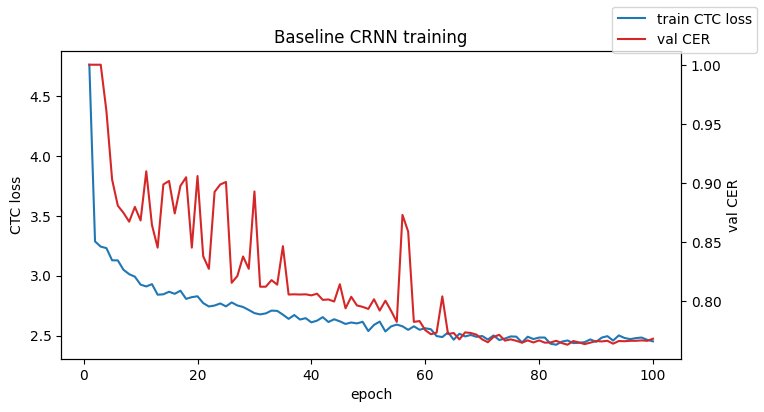

In [10]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history["epoch"], history["train_loss"], label="train CTC loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("CTC loss")
ax2 = ax1.twinx()
ax2.plot(history["epoch"], history["CER"], color="tab:red", label="val CER")
ax2.set_ylabel("val CER")
fig.legend(loc="upper right"); plt.title("Baseline CRNN training"); plt.show()

## 10. Test-set evaluation & error analysis

Reload the **best** checkpoint (not the last epoch) before final evaluation, and look at
the failure cases — the confusion pairs you find here (e.g. visually similar medicine
names) are the qualitative evidence for the Gap Analysis chapter.

In [11]:
ckpt = torch.load(CFG.ckpt_dir / "best.pt", map_location="cpu")
model.load_state_dict(ckpt["model"]); model.to(DEVICE)

test_metrics, test_preds, test_refs = evaluate(model, test_dl, VOCAB)
print("BASELINE CRNN — test:", {k: round(v, 4) if isinstance(v, float) else v
                                 for k, v in test_metrics.items()})

errors = [(r, p, edit_distance(p, r)) for p, r in zip(test_preds, test_refs) if p != r]
errors.sort(key=lambda e: -e[2])
err_df = pd.DataFrame(errors, columns=["reference", "prediction", "edit_distance"])
err_df.to_csv(CFG.ckpt_dir / "baseline_errors.csv", index=False)
print(f"\n{len(errors)} errors / {len(test_refs)} samples. Worst 15:")
err_df.head(15)

BASELINE CRNN — test: {'CER': 0.7841, 'ExactMatch': 0.0202, 'WER': 0.9798, 'n': 793}

777 errors / 793 samples. Worst 15:


,reference,prediction,edit_distance
0,spironolactone 25mg,elmg,16
1,rosuvastatin 10mg,e0mg,14
2,esotid mups(zx),neubole,14
3,telecordip plus,celtone,12
4,phauolid soaf,nele,12
5,tab. ouocm-d,nellen,12
6,nexum mups 20,ena,12
7,atorvastatin 5mg,asmg,12
8,flucloxacillin,emtole,12
9,augmentin 625mg,em0mg,12


## 11. Single-image inference
Utility for the viva demo and for spot-checking pharmacy images later.

In [12]:
@torch.no_grad()
def predict_image(path: str | Path, model: nn.Module, vocab: Vocab, cfg: Config) -> str:
    img = Image.open(path).convert("L")
    w, h = img.size
    new_w = min(max(8, int(round(w * cfg.img_height / h))), cfg.max_width)
    img = img.resize((new_w, cfg.img_height), Image.BILINEAR)
    x = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0)[None, None].to(DEVICE)
    model.eval()
    return greedy_decode(model(x).cpu(), vocab)[0]

# Example (uncomment with a real path):
# print(predict_image(CFG.data_root / CFG.test_img_dir / "example.png", model, VOCAB, CFG))

## 12. What to record for the thesis (do this now, not at write-up)

1. **Methodology table:** every value in `Config`, parameter count, device, torch version.
2. **Results table:** test CER / WER / Exact Match with the number of test samples.
3. **Error inventory:** `baseline_errors.csv` — categorise the top errors (look-alike
   confusion vs illegibility vs preprocessing artefact). This feeds Gap Analysis §(a).
4. **Training cost:** wall-clock per epoch on the M4 Pro — evidence for the
   "feasible local training" claim in the methodology.

**Next notebook (02):** hybrid CNN + Transformer encoder with joint CTC–attention and
lexicon-constrained decoding, evaluated with the *same* `corpus_metrics` functions and
the *same* splits so the comparison is controlled.